In [28]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import hashlib

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.inspection import permutation_importance

### Editing the CSVs

In [3]:
data_path = os.path.join(os.getcwd(), "data")
files = os.listdir(data_path)

In [ ]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    try:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["mean_ICP"]
    except:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["ICP"]

    try:
        df_individual = df_individual.rename(columns={
        "RAP_1min": "RAP",
        "mean_ICP": "ICP",
        "meanAMP": "AMP"
        })
    except:
        pass

    df_individual.to_csv(os.path.join(data_path, file), index=False)

### Converting the Datetime Format

In [ ]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"], origin="1899-12-30", unit="D")
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

### Adding Time-minutes Column

In [ ]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    # converting to datetime
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"])
    df_individual["time_minutes"] = (df_individual["DateTime"] - df_individual["DateTime"].iloc[0]).dt.total_seconds() / 60
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

### Demographic File

In [10]:
demographic_df = pd.read_excel(os.path.join(data_path, "Winnipeg_TBI_demographics.xlsx"))

In [19]:
def format_id(x):
    return f"TBI_{int(x[3:]):03d}"

In [20]:
# Standardizing demographic column names
demographic_df = demographic_df.rename(columns={
    "ID": "patient_id",
    "Age (years)": "age",
    "Sex (M/F)": "sex"
})

# Cleaning ID and sex
demographic_df["patient_id"] = demographic_df["patient_id"].astype(str).str.strip()
demographic_df["sex"] = demographic_df["sex"].astype(str).str.strip().str.upper()
demographic_df = demographic_df[["patient_id", "age", "sex"]].copy()

demographic_df["patient_id"] = demographic_df["patient_id"].apply(format_id)

print("Demographic rows:", len(demographic_df))
demographic_df.head()

Demographic rows: 113


,patient_id,age,sex
0,TBI_001,42,M
1,TBI_002,54,M
2,TBI_003,24,M
3,TBI_004,32,M
4,TBI_005,27,M


In [11]:
output_dir = os.path.join(os.getcwd(), "privacy_outputs_3h")
os.makedirs(output_dir, exist_ok=True)

In [30]:
df_individual.head()

,DateTime,RAP,ICP,AMP,MAP,CPP
0,2019-01-04 18:19:24.389869664,NaN,NaN,NaN,NaN,NaN
1,2019-01-04 18:20:24.389874257,NaN,13.93,1.891,119.3,105.37
2,2019-01-04 18:21:24.389870685,NaN,13.31,1.842,120.0,106.69
3,2019-01-04 18:22:24.389875277,0.8784,13.87,1.924,117.7,103.83
4,2019-01-04 18:23:24.389871074,0.6063,13.90,1.854,118.8,104.90


## Privacy preprocessing helpers

In [16]:
def anonymize_value(x, prefix="anon"):
    if pd.isna(x):
        return np.nan
    digest = hashlib.sha256(str(x).encode()).hexdigest()[:12]
    return f"{prefix}_{digest}"

In [17]:
def age_to_bin(age):
    if pd.isna(age):
        return np.nan
    age = float(age)
    if age < 30:
        return "18-29"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    elif age < 70:
        return "60-69"
    else:
        return "70+"

In [50]:
def deidentify_clinical_dataframe(df, file_name, demographic_df):
    df = df.copy()
    source_patient_id = file_name[:7]

    privacy_log = {
        "source_file": file_name,
        "source_patient_id": source_patient_id,
        "rows_before": len(df),
        "columns_before": list(df.columns),
        "demographic_match_found": False,
        "id_columns_removed": [],
        "direct_identifier_columns_removed": [],
        "used_datetime": "DateTime" in df.columns,
        "created_time_minutes": False,
        "age_binned": False,
        "sex_standardized": False
    }

    # Adding source file patient ID for merge if no explicit ID exists in signal file
    if "patient_id" not in df.columns:
        df["patient_id"] = source_patient_id

    df["patient_id"] = df["patient_id"].astype(str).str.strip()

    # Merge demographic fields
    df = df.merge(
        demographic_df[["patient_id", "age", "sex"]],
        on="patient_id",
        how="left"
    )

    if df["age"].notna().any() or df["sex"].notna().any():
        privacy_log["demographic_match_found"] = True

   # Createing anonymized patient ID from raw ID
    df["anon_patient_id"] = df["patient_id"].apply(lambda x: anonymize_value(x, prefix="pt"))

    # Age binning
    if "age" in df.columns:
        df["age_group"] = df["age"].apply(age_to_bin)
        df = df.drop(columns=["age"])
        privacy_log["age_binned"] = True

    # Standardizing sex
    if "sex" in df.columns:
        df["sex_group"] = df["sex"].replace({
            "M": "Male",
            "F": "Female"
        })
        df = df.drop(columns=["sex"])
        privacy_log["sex_standardized"] = True

    if "DateTime" in df.columns:

        df["DateTime"] = pd.to_datetime(df["DateTime"])
        # Getting start time (per patient)
        start_time = df["DateTime"].min()
    
        # Converting to relative time in minutes
        if pd.notna(start_time):
            df["time_minutes"] = (df["DateTime"] - start_time).dt.total_seconds() / 60
            privacy_log["created_time_minutes"] = True
        else:
            df["time_minutes"] = np.nan
    
        # Removing absolute timestamps (privacy step)
        df = df.drop(columns=["DateTime"])

    df = df.sort_values("time_minutes").reset_index(drop=True)
    privacy_log["rows_after"] = len(df)
    privacy_log["columns_after"] = list(df.columns)

    return df, privacy_log

## Event and feature engineering helpers

In [42]:
def first_sustained_event_time(df, threshold, consecutive_minutes):
    """
    Returns the first time_minutes at which a sustained RAP < threshold
    episode starts, or None if no sustained event exists.
    """
    rap = df["RAP"].values
    times = df["time_minutes"].values

    below = pd.Series(rap < threshold)

    run_length = 0
    start_idx = None

    for i, val in enumerate(below):
        if pd.isna(rap[i]):
            run_length = 0
            start_idx = None
            continue

        if val:
            if run_length == 0:
                start_idx = i
            run_length += 1

            if run_length >= consecutive_minutes:
                return times[start_idx]
        else:
            run_length = 0
            start_idx = None

    return None

def compute_slope(time_values, signal_values):
    valid = pd.DataFrame({"t": time_values, "y": signal_values}).dropna()
    if len(valid) < 2:
        return np.nan
    return np.polyfit(valid["t"], valid["y"], 1)[0]

def add_signal_summary_features(df_early, signal, suffix, feats):
    signal_lower = signal.lower()

    feats[f"{signal_lower}_mean_{suffix}"] = df_early[signal].mean()
    feats[f"{signal_lower}_std_{suffix}"] = df_early[signal].std()
    feats[f"{signal_lower}_min_{suffix}"] = df_early[signal].min()
    feats[f"{signal_lower}_max_{suffix}"] = df_early[signal].max()
    feats[f"{signal_lower}_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early[signal])
    return feats

def extract_early_features(df_early, window_hours):
    feats = {}
    suffix = f"{window_hours}h"

    for signal in ["RAP", "ICP", "MAP", "CPP", "AMP"]:
        feats = add_signal_summary_features(df_early, signal, suffix, feats)

    if "RAP" in df_early.columns:
        feats[f"pct_rap_gt_0_4_{suffix}"] = (df_early["RAP"] > 0.4).mean() * 100
        feats[f"pct_rap_0_to_0_4_{suffix}"] = ((df_early["RAP"] >= 0) & (df_early["RAP"] <= 0.4)).mean() * 100
        feats[f"pct_rap_lt_0_{suffix}"] = (df_early["RAP"] < 0).mean() * 100

    # Privacy-safe demographic features
    if "age_group" in df_early.columns:
        feats["age_group"] = df_early["age_group"].dropna().iloc[0] if df_early["age_group"].notna().any() else np.nan

    if "sex_group" in df_early.columns:
        feats["sex_group"] = df_early["sex_group"].dropna().iloc[0] if df_early["sex_group"].notna().any() else np.nan

    # Add optional physiological parameters automatically
    core_cols = {
        "anon_patient_id", "time_minutes", "RAP", "ICP", "MAP", "CPP", "AMP",
        "age_group", "sex_group"
    }

    return feats

## Load, de-identify, and inspect privacy processing

In [51]:
deidentified_data = {}
privacy_logs = []

for file in files:
    try:
        df_raw = pd.read_csv(os.path.join(data_path, file))
        df_priv, log = deidentify_clinical_dataframe(df_raw, file, demographic_df)
        deidentified_data[file] = df_priv
        privacy_logs.append(log)
    except Exception as e:
        privacy_logs.append({
            "source_file": file,
            "source_patient_id": os.path.splitext(file)[0],
            "error": str(e)
        })

privacy_report = pd.DataFrame(privacy_logs)
privacy_report.head()

,source_file,source_patient_id,rows_before,columns_before,demographic_match_found,id_columns_removed,direct_identifier_columns_removed,used_datetime,created_time_minutes,age_binned,sex_standardized,rows_after,columns_after
0,TBI_001.csv,TBI_001,8853,"[DateTime, RAP, ICP, AMP, MAP, CPP, time_minutes]",True,[],[],True,True,True,True,8853,"[RAP, ICP, AMP, MAP, CPP, time_minutes, patien..."
1,TBI_002.csv,TBI_002,1873,"[DateTime, RAP, ICP, AMP, MAP, CPP, time_minutes]",True,[],[],True,True,True,True,1873,"[RAP, ICP, AMP, MAP, CPP, time_minutes, patien..."
2,TBI_003.csv,TBI_003,2237,"[DateTime, RAP, ICP, AMP, MAP, CPP, time_minutes]",True,[],[],True,True,True,True,2237,"[RAP, ICP, AMP, MAP, CPP, time_minutes, patien..."
3,TBI_004.csv,TBI_004,442,"[DateTime, RAP, ICP, AMP, MAP, CPP, time_minutes]",True,[],[],True,True,True,True,442,"[RAP, ICP, AMP, MAP, CPP, time_minutes, patien..."
4,TBI_007.csv,TBI_007,754,"[DateTime, RAP, ICP, AMP, MAP, CPP, time_minutes]",True,[],[],True,True,True,True,754,"[RAP, ICP, AMP, MAP, CPP, time_minutes, patien..."


In [52]:
privacy_report.to_csv(os.path.join(output_dir, "privacy_report_3h.csv"), index=False)

print("Files processed:", privacy_report["source_file"].nunique())
print("Files with demographic match:", privacy_report["demographic_match_found"].fillna(False).sum())
print("Files with successful time conversion:", privacy_report["created_time_minutes"].fillna(False).sum())
print("Files with explicit ID columns removed:", (privacy_report["id_columns_removed"].astype(str) != "[]").sum())
print("Files with direct identifiers removed:", (privacy_report["direct_identifier_columns_removed"].astype(str) != "[]").sum())
print("Files with age binning:", privacy_report["age_binned"].fillna(False).sum())
print("Files with sex standardization:", privacy_report["sex_standardized"].fillna(False).sum())

Files processed: 109
Files with demographic match: 109
Files with successful time conversion: 109
Files with explicit ID columns removed: 0
Files with direct identifiers removed: 0
Files with age binning: 109
Files with sex standardization: 109


## Main 3-hour landmark survival cohort construction

In [56]:
LANDMARK_HOURS = 3
LANDMARK_MINUTES = LANDMARK_HOURS * 60

SUSTAINED_MINUTES = 10
THRESHOLD = -0.1
TEST_SIZE = 0.30
RANDOM_STATE = 42

In [58]:
rows = []
excluded_early_event = []
excluded_short_followup = []
excluded_bad_file = []

for file, df_individual in deidentified_data.items():
    patient_id = df_individual["anon_patient_id"].iloc[0] if len(df_individual) > 0 else get_source_patient_token(file)

    try:
        if "RAP" not in df_individual.columns or "time_minutes" not in df_individual.columns:
            excluded_bad_file.append(patient_id)
            continue

        first_valid = df_individual["RAP"].first_valid_index()
        last_valid = df_individual["RAP"].last_valid_index()

        if first_valid is None or last_valid is None:
            excluded_bad_file.append(patient_id)
            continue

        df_individual = df_individual.loc[first_valid:last_valid].copy().reset_index(drop=True)

        max_time = df_individual["time_minutes"].max()
        if pd.isna(max_time) or max_time <= LANDMARK_MINUTES:
            excluded_short_followup.append(patient_id)
            continue

        first_event_time = first_sustained_event_time(
            df_individual,
            threshold=THRESHOLD,
            consecutive_minutes=SUSTAINED_MINUTES
        )

        if first_event_time is not None and first_event_time <= LANDMARK_MINUTES:
            excluded_early_event.append(patient_id)
            continue

        df_early = df_individual[df_individual["time_minutes"] <= LANDMARK_MINUTES].copy()
        early_features = extract_early_features(df_early, LANDMARK_HOURS)

        if first_event_time is None:
            event_observed = 0
            time_to_event = max_time - LANDMARK_MINUTES
        else:
            event_observed = 1
            time_to_event = first_event_time - LANDMARK_MINUTES

        row = {
            "anon_patient_id": patient_id,
            "event_observed": event_observed,
            "time_to_event": time_to_event,
            "max_followup_minutes": max_time
        }
        row.update(early_features)
        rows.append(row)

    except Exception as e:
        excluded_bad_file.append(patient_id)
        print(f"Failed on {file}: {e}")

survival_df = pd.DataFrame(rows)
print("Included patients =", len(survival_df))
print("Excluded: early event <=", LANDMARK_MINUTES, "minutes =", len(excluded_early_event))
print("Excluded: too short follow-up =", len(excluded_short_followup))
print("Excluded: bad/empty files =", len(excluded_bad_file))

survival_df.head()

Included patients = 78
Excluded: early event <= 180 minutes = 29
Excluded: too short follow-up = 2
Excluded: bad/empty files = 0


,anon_patient_id,event_observed,time_to_event,max_followup_minutes,rap_mean_3h,rap_std_3h,rap_min_3h,rap_max_3h,rap_slope_3h,icp_mean_3h,...,amp_mean_3h,amp_std_3h,amp_min_3h,amp_max_3h,amp_slope_3h,pct_rap_gt_0_4_3h,pct_rap_0_to_0_4_3h,pct_rap_lt_0_3h,age_group,sex_group
0,pt_d63559c0a530,1,720.000000,8782.007517,0.691427,0.357456,-0.8324,0.9977,-0.001082,12.851277,...,2.135708,0.686403,0.0730,4.2820,-0.008393,87.640449,3.932584,8.426966,40-49,Male
1,pt_8c95f85f0356,0,1538.000000,1718.000000,0.713443,0.377988,-0.9757,0.9995,-0.000488,8.944371,...,4.887837,1.104530,2.3850,6.9080,0.002011,84.269663,8.988764,6.741573,50-59,Male
2,pt_7164a38d8133,0,2470.561632,2650.561632,0.597290,0.437117,-0.9928,1.0000,0.002037,19.000852,...,0.621151,0.127366,0.1765,0.9227,-0.000627,77.401130,11.299435,11.299435,18-29,Male
3,pt_f205725c0a7d,0,1658.092167,1838.092167,0.724582,0.354157,-0.5323,0.9979,0.004806,9.444250,...,2.140457,0.283263,1.0100,2.7270,-0.004061,85.869565,7.608696,6.521739,70+,Male
4,pt_bccae91936d7,1,62.512164,8333.524664,0.326813,0.671496,-0.9834,0.9948,-0.036379,4.671382,...,1.200082,0.275006,0.0461,1.5810,-0.005133,40.816327,18.367347,18.367347,50-59,Male


In [59]:
suffix = f"{LANDMARK_HOURS}h"

if len(survival_df) > 0:
    print(f"Later events after {suffix} =", int(survival_df["event_observed"].sum()))
    print("Censored =", int((survival_df["event_observed"] == 0).sum()))
    print(f"Median follow-up after {suffix} (minutes) =", survival_df["time_to_event"].median())

survival_df.to_csv(os.path.join(output_dir, f"patient_level_survival_dataset_privacy_{suffix}.csv"), index=False)

Later events after 3h = 52
Censored = 26
Median follow-up after 3h (minutes) = 1480.675299265367


## Kaplan-Meier analysis

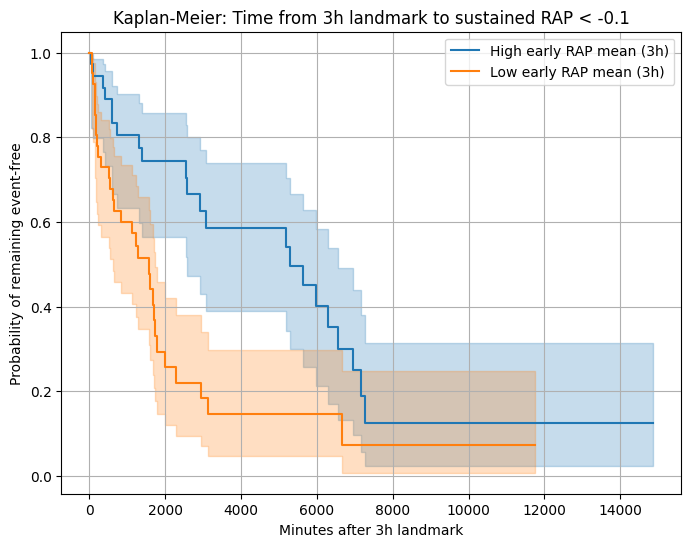

In [60]:
kmf = KaplanMeierFitter()
col_name = f"rap_mean_{suffix}"

median_rap = survival_df[col_name].median()
survival_df["rap_group"] = np.where(
    survival_df[col_name] >= median_rap,
    f"High early RAP mean ({suffix})",
    f"Low early RAP mean ({suffix})"
)

plt.figure(figsize=(8, 6))
for group_name, group_df in survival_df.groupby("rap_group"):
    kmf.fit(
        durations=group_df["time_to_event"],
        event_observed=group_df["event_observed"],
        label=group_name
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan-Meier: Time from {suffix} landmark to sustained RAP < -0.1")
plt.xlabel(f"Minutes after {suffix} landmark")
plt.ylabel("Probability of remaining event-free")
plt.grid(True)
#plt.savefig(os.path.join(output_dir, f"km_curve_{suffix}_rap_privacy.jpg"), dpi=300, bbox_inches="tight")
plt.show()

In [61]:
g1 = survival_df[survival_df["rap_group"] == f"High early RAP mean ({suffix})"]
g2 = survival_df[survival_df["rap_group"] == f"Low early RAP mean ({suffix})"]

result = logrank_test(
    g1["time_to_event"], g2["time_to_event"],
    event_observed_A=g1["event_observed"],
    event_observed_B=g2["event_observed"]
)

print("Log-rank p-value:", result.p_value)

Log-rank p-value: 0.001474435192614067


## Cox proportional hazards model

In [62]:
candidate_cox_features = [
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}",
    "age_group",
    "sex_group"
]

candidate_cox_features = [c for c in candidate_cox_features if c in survival_df.columns]

cox_cols = ["time_to_event", "event_observed"] + candidate_cox_features
cox_df = survival_df[cox_cols].dropna().copy()

# One-hot encode privacy-safe categorical demographics
categorical_cols = [c for c in ["age_group", "sex_group"] if c in cox_df.columns]
if categorical_cols:
    cox_df = pd.get_dummies(cox_df, columns=categorical_cols, drop_first=True)

cox_df.head()

,time_to_event,event_observed,rap_mean_3h,icp_mean_3h,cpp_mean_3h,map_mean_3h,amp_mean_3h,age_group_30-39,age_group_40-49,age_group_50-59,age_group_60-69,age_group_70+,sex_group_Male
0,720.000000,1,0.691427,12.851277,95.395557,108.430176,2.135708,False,True,False,False,False,True
1,1538.000000,0,0.713443,8.944371,79.439056,88.383427,4.887837,False,False,True,False,False,True
2,2470.561632,0,0.597290,19.000852,64.864343,83.838750,0.621151,False,False,False,False,False,True
3,1658.092167,0,0.724582,9.444250,64.628141,74.072391,2.140457,False,False,False,False,True,True
4,62.512164,1,0.326813,4.671382,82.817147,87.684722,1.200082,False,False,True,False,False,True


In [63]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_event", event_col="event_observed")
cph.print_summary()

cox_summary = cph.summary[["coef", "exp(coef)", "p"]].copy()
cox_summary.to_csv(os.path.join(output_dir, f"cox_summary_privacy_{suffix}.csv"))
print("C-index:", cph.concordance_index_)
cox_summary

<lifelines.CoxPHFitter: fitted with 70 total observations, 23 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 70
number of events observed = 47
   partial log-likelihood = -146.33
         time fit was run = 2026-04-24 16:33:07 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
rap_mean_3h     -3.84      0.02      1.17           -6.13           -1.55                0.00                0.21
icp_mean_3h      0.06      1.07      0.05           -0.03            0.16                0.97                1.17
cpp_mean_3h      0.04      1.04      0.02           -0.01            0.09                0.99                1.09
map_mean_3h     -0.03      0.97      0.03           -0.09            0.03                0.91                1.03
amp_mean_3h     -0.02      0.98      0.19           -0.40            0.35                0.67                1.42
age_group_30-39  0.46      1.58      0.63           -0.77            1.68                0.46                5.39
age_group_40-49  0.65      1.91      0.46           -0.25            1.54                0.78                4.67
age_group_50-59  0.56      1.75      0.68           -0.78            1.90                0.46                6.70
age_group_60-69  0.31      1.37      0.57           -0.81            1.44                0.44                4.22
age_group_70+    1.75      5.76      0.63            0.52            2.99                1.68               19.81
sex_group_Male   0.69      1.99      0.45           -0.19            1.56                0.83                4.77

                 cmp to     z      p  -log2(p)
covariate                                     
rap_mean_3h        0.00 -3.29 <0.005      9.95
icp_mean_3h        0.00  1.36   0.17      2.52
cpp_mean_3h        0.00  1.73   0.08      3.57
map_mean_3h        0.00 -1.07   0.29      1.80
amp_mean_3h        0.00 -0.13   0.90      0.16
age_group_30-39    0.00  0.73   0.46      1.11
age_group_40-49    0.00  1.42   0.16      2.68
age_group_50-59    0.00  0.82   0.41      1.27
age_group_60-69    0.00  0.55   0.58      0.77
age_group_70+      0.00  2.78   0.01      7.52
sex_group_Male     0.00  1.53   0.12      3.00
---
Concordance = 0.72
Partial AIC = 314.67
log-likelihood ratio test = 27.27 on 11 df
-log2(p) of ll-ratio test = 7.90

C-index: 0.7189097103918228


,coef,exp(coef),p
covariate,,,
rap_mean_3h,-3.841495,0.021462,0.001012
icp_mean_3h,0.064403,1.066522,0.174778
cpp_mean_3h,0.039994,1.040804,0.084461
map_mean_3h,-0.031340,0.969146,0.286388
amp_mean_3h,-0.024731,0.975572,0.897569
age_group_30-39,0.458085,1.581044,0.464070
age_group_40-49,0.646896,1.909604,0.156211
age_group_50-59,0.560021,1.750710,0.413412
age_group_60-69,0.313952,1.368823,0.584570


## Random Survival Forest

In [64]:
y = Surv.from_dataframe(
    event="event_observed",
    time="time_to_event",
    data=survival_df
)

feature_cols = [
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}"
]

feature_cols = [c for c in feature_cols if c in survival_df.columns]

X = survival_df[feature_cols].copy()

# Add privacy-safe demographic features
if "age_group" in survival_df.columns:
    X["age_group"] = survival_df["age_group"]

if "sex_group" in survival_df.columns:
    X["sex_group"] = survival_df["sex_group"]

X = pd.get_dummies(X, columns=[c for c in ["age_group", "sex_group"] if c in X.columns], drop_first=True)
X = X.dropna().copy()
y = y[X.index]

print("RSF features:", list(X.columns))
print("Number of rows for RSF:", len(X))

RSF features: ['rap_mean_3h', 'icp_mean_3h', 'cpp_mean_3h', 'map_mean_3h', 'amp_mean_3h', 'age_group_30-39', 'age_group_40-49', 'age_group_50-59', 'age_group_60-69', 'age_group_70+', 'sex_group_Male']
Number of rows for RSF: 70


In [65]:
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

rsf.fit(X_train, y_train)

cindex_test = concordance_index_censored(
    y_test["event_observed"],
    y_test["time_to_event"],
    rsf.predict(X_test)
)[0]

print("Test C-index:", cindex_test)

Test C-index: 0.6064516129032258


rap_mean_3h        0.050645
cpp_mean_3h        0.024516
age_group_40-49    0.022903
map_mean_3h        0.019677
sex_group_Male     0.003548
age_group_50-59    0.001613
age_group_70+      0.000323
age_group_30-39    0.000000
age_group_60-69   -0.001935
icp_mean_3h       -0.015161
amp_mean_3h       -0.047097
dtype: float64


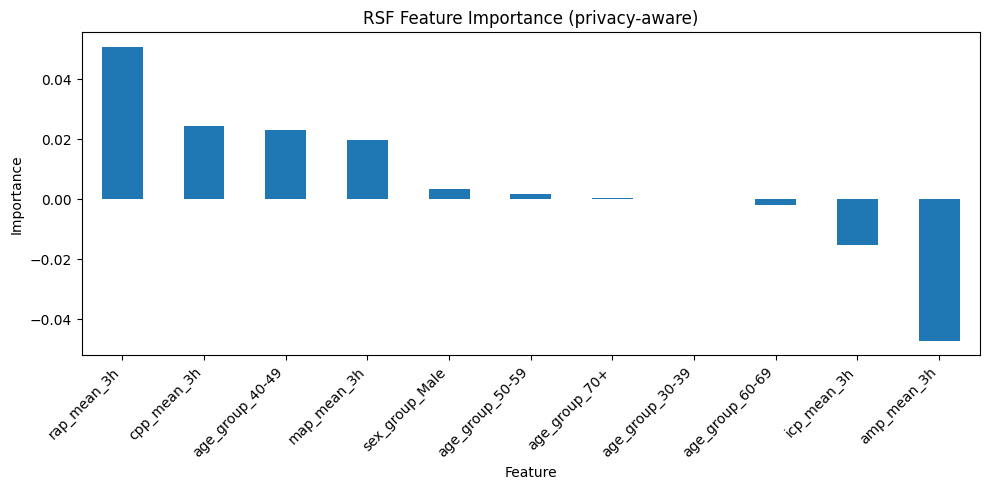

In [67]:
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importance.to_csv(os.path.join(output_dir, f"rsf_importance_privacy_{suffix}.csv"))
print(importance)

importance.plot(kind="bar", figsize=(10, 5))
plt.title("RSF Feature Importance (privacy-aware)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, f"rsf_feat_imp_{suffix}_privacy.jpg"), dpi=300, bbox_inches="tight")
plt.show()